## Deep Learning

### Chapter 14: Neural Networks for Text Classification (Transformers + Self-Attention + Sequence Models)

Text classification is a common task in natural language processing (NLP) that involves assigning predefined categories or labels to text data. In this chapter, we will explore how to build neural networks for text classification using deep learning techniques.

### 0. Define the libraries

In [53]:
import re
import string
import unicodedata
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# Add seed to ensure reproducibility
np.random.seed(42)

### 1. Data Preprocessing

We will use the IMDB dataset, which contains movie reviews labeled as positive or negative. We will preprocess the text data by tokenizing the sentences and converting them into sequences of integers.

**1.1. Loading the IMDB Dataset**

In [25]:
dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

dataset_path = keras.utils.get_file(
    "aclImdb_v1",
    dataset_url,
    untar=True,
    cache_dir=".",
    cache_subdir=""
)

dataset_dir = os.path.join(os.path.dirname(dataset_path), "aclImdb")

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 111s 1us/step


In [30]:
train_dir = "./aclImdb_v1/aclImdb/train"
test_dir = "./aclImdb_v1/aclImdb/test"

In [71]:
# 1. Load the dataset, explicitly defining class_names to ignore 'unsup'
# Note that the IMDB dataset used here has another folder called 'unsup' which contains unsupervised data. 
# We will ignore that folder by explicitly defining the class_names argument.
class_names = ['neg', 'pos']

train_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    class_names=class_names,
    validation_split=0.2,
    subset='training',
    seed=42,
    batch_size=32,
)

val_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    class_names=class_names,
    validation_split=0.2,
    subset='validation',
    seed=42,
    batch_size=32,
)

test_ds = keras.utils.text_dataset_from_directory(
    test_dir,
    class_names=class_names,
    batch_size=32,
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


In [72]:
# Get all class label and its name
print("Class names:", train_ds.class_names)

# Put all unique word and occurrence as dataframe
def get_word_occurrence(dataset):
    word_occurrence = {}
    for reviews, labels in dataset:
        for review in reviews.numpy():
            review_text = review.decode("utf-8")
            words = re.findall(r'\b\w+\b', review_text.lower())
            for word in words:
                if word in word_occurrence:
                    word_occurrence[word] += 1
                else:
                    word_occurrence[word] = 1
    return pd.DataFrame(list(word_occurrence.items()), columns=['Word', 'Occurrence']).sort_values(by='Occurrence', 
                                                                                                   ascending=False)

# Reset index of the dataframe
get_word_occurrence(train_ds).reset_index(drop=True).head(20)

Class names: ['neg', 'pos']


,Word,Occurrence
0,the,270439
1,and,131884
2,a,130524
3,of,117258
4,to,108498
5,is,85991
6,br,81805
7,it,77160
8,in,75139
9,i,70231


In [73]:
for reviews, labels in train_ds.take(1):
    for i in range(3):
        review = reviews.numpy()[i].decode("utf-8")
        # Insert a newline after every period followed by a space
        review = review.replace(". ", ".\n")
        print("Review:")
        print(review)
        print("+ Label:", labels.numpy()[i])
        print("-" * 80)

Review:
Having seen most of Ringo Lam's films, I can say that this is his best film to date, and the most unusual.
It's a ancient china period piece cranked full of kick-ass martial arts, where the location of an underground lair full of traps and dungeons plays as big a part as any of the characters.
The action is fantastic, the story is tense and entertaining, and the set design is truely memorable.
Sadly, Burning Paradise has not been made available on DVD and vhs is next-to-impossible to get your mitts on, even if you near the second biggest china-town in North America (like I do).
If you can find it, don't pass it up.
+ Label: 1
--------------------------------------------------------------------------------
Review:
Caution: May contain spoilers...<br /><br />I've seen this movie 3 times & I've liked it every time.
Upon seeing it again, I'm always reminded of how good it is.
An HBO TV movie- very well done like most of their movies are- this would've gotten Oscars for it's perform

**1.2. Text Standardization and Tokenization**

Standardizing the text involves converting it to lowercase, removing punctuation, and handling special characters. Tokenization is the process of splitting the text into individual words or tokens.

In [74]:
def remove_accents(text):
    normalized = unicodedata.normalize("NFD", text)
    return "".join(ch for ch in normalized 
                   if unicodedata.category(ch) != "Mn")


def standardize_text(text, strip_accents=False):
    text = text.lower()

    if strip_accents:
        text = remove_accents(text)

    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_words(text):
    return standardize_text(text).split()

In [75]:
# Test on a sample review
sample_review = "This movie was AMAZING! I loved it. The acting was great, and the plot was engaging. Highly recommend!"
for sentence in sample_review.split('.'):
    print("Original :", sentence)
    print("Cleaned  :", standardize_text(sentence))
    print("Tokens   :", tokenize_words(sentence))
    print()

Original : This movie was AMAZING! I loved it
Cleaned  : this movie was amazing i loved it
Tokens   : ['this', 'movie', 'was', 'amazing', 'i', 'loved', 'it']

Original :  The acting was great, and the plot was engaging
Cleaned  : the acting was great and the plot was engaging
Tokens   : ['the', 'acting', 'was', 'great', 'and', 'the', 'plot', 'was', 'engaging']

Original :  Highly recommend!
Cleaned  : highly recommend
Tokens   : ['highly', 'recommend']



**1.3. Building a Vocabulary and Encoding Text**

This step involves creating a vocabulary of unique words from the dataset and encoding the text data into sequences of integers based on this vocabulary.

In [76]:
vocab = {"": 0, "[UNK]": 1,}

for reviews, _ in train_ds:

    for review in reviews.numpy():
        text = review.decode("utf-8")
        
        for token in tokenize_words(text):
            if token not in vocab:
                vocab[token] = len(vocab)

inverse_vocab = {idx: token 
                 for token, idx in vocab.items()}

In [77]:
def encode_text(text, vocab):
    return [vocab.get(token, vocab["[UNK]"]) 
            for token in tokenize_words(text)]


def decode_ids(ids, inverse_vocab):
    return " ".join(inverse_vocab[idx] 
                    for idx in ids if idx != 0)

In [78]:
# Test the standardize_text and tokenize_words functions with unknown words
test_sentences = [
    "This movie was AMAZING! I loved it. The acting was great, and the plot was engaging. Highly recommend!",
    "C'était un film incroyable! J'ai adoré. Le jeu d'acteur était excellent et l'intrigue captivante. Je recommande vivement!",
    "The cinematography was breathtaking, and the soundtrack perfectly complemented the scenes.",
    "I found the pacing of the movie to be a bit slow, but the character development made up for it.",
    "The ending was unexpected and left me thinking about the story long after it finished."
]

sample = " ".join(test_sentences)
encoded = encode_text(sample, vocab)

print("Vocabulary size:", len(vocab))
print("Original :", sample)
print("Encoded  :", encoded)
print("Decoded  :", decode_ids(encoded, inverse_vocab))

Vocabulary size: 107580
Original : This movie was AMAZING! I loved it. The acting was great, and the plot was engaging. Highly recommend! C'était un film incroyable! J'ai adoré. Le jeu d'acteur était excellent et l'intrigue captivante. Je recommande vivement! The cinematography was breathtaking, and the soundtrack perfectly complemented the scenes. I found the pacing of the movie to be a bit slow, but the character development made up for it. The ending was unexpected and left me thinking about the story long after it finished.
Encoded  : [145, 285, 440, 689, 234, 3330, 64, 7, 279, 440, 222, 12, 7, 1228, 440, 2707, 3937, 438, 1, 26089, 243, 1, 33933, 1, 3806, 54464, 1, 89733, 1537, 5505, 1, 1, 22269, 1, 103012, 7, 4849, 440, 6120, 12, 7, 2045, 2610, 7763, 7, 291, 234, 542, 7, 2883, 10, 7, 285, 18, 117, 26, 551, 1570, 80, 7, 402, 403, 397, 116, 68, 64, 7, 205, 440, 1229, 12, 103, 434, 1489, 259, 7, 184, 409, 761, 64, 6870]
Decoded  : this movie was amazing i loved it the acting was grea

**1.4. TensorFlow’s TextVectorization Layer**

The TextVectorization layer in TensorFlow simplifies the process of text preprocessing by providing a built-in method for tokenization, vocabulary building, and encoding.

In [79]:
# Extract only review texts
train_text = train_ds.map(lambda x, y: x)

sample_batch = tf.constant(["this movie was surprisingly good"])

vectorizers = {
    "Integer Sequence":
        TextVectorization(
            max_tokens=20000,
            output_mode="int",
            output_sequence_length=10
        ),

    "Multi-Hot":
        TextVectorization(
            max_tokens=20000,
            output_mode="multi_hot"
        ),

    "Count":
        TextVectorization(
            max_tokens=20000,
            output_mode="count"
        ),

    "TF-IDF (Bigram)":
        TextVectorization(
            max_tokens=20000,
            output_mode="tf_idf",
            ngrams=2
        ),
}

for name, layer in vectorizers.items():

    layer.adapt(train_text)

    print("=" * 60)
    print(name)
    print(layer(sample_batch).numpy()[0])

Integer Sequence
[  11   18   14 1187   50    0    0    0    0    0]
Multi-Hot
[0 0 0 ... 0 0 0]


2026-07-03 11:10:45.715385: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Count
[0 0 0 ... 0 0 0]
TF-IDF (Bigram)
[5.3294396 0.        0.        ... 0.        0.        0.       ]


### 2. Bag-of-Words Sentiment Classifier

This is a simple example of a bag-of-words sentiment classifier using a feedforward neural network. The model takes in a bag-of-words representation of the input text and predicts whether the sentiment is positive or negative.

**2.1. Building a Bag-of-Words Sentiment Classifier**

In [80]:
bow_vectorizer = TextVectorization(max_tokens=20000, 
                                   ngrams=2, 
                                   output_mode="multi_hot",)

bow_vectorizer.adapt(train_text)

inputs = keras.Input(shape=(), dtype=tf.string,)

x = bow_vectorizer(inputs)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

bow_model = keras.Model(inputs, outputs)
bow_model.compile(optimizer="adam", loss="binary_crossentropy", 
                  metrics=["accuracy"])

In [81]:
history = bow_model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8658 - loss: 0.3197 - val_accuracy: 0.8960 - val_loss: 0.2591
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9548 - loss: 0.1286 - val_accuracy: 0.8898 - val_loss: 0.2865
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9816 - loss: 0.0580 - val_accuracy: 0.8888 - val_loss: 0.3351
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9918 - loss: 0.0285 - val_accuracy: 0.8852 - val_loss: 0.3768
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9962 - loss: 0.0165 - val_accuracy: 0.8814 - val_loss: 0.4365
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9962 - loss: 0.0125 - val_accuracy: 0.8800 - val_loss: 0.4830
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9979 - loss: 0.0091 - val_accuracy: 0.8832 - val_loss: 0.5093
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9975 - loss: 0.0094 - val_accurac

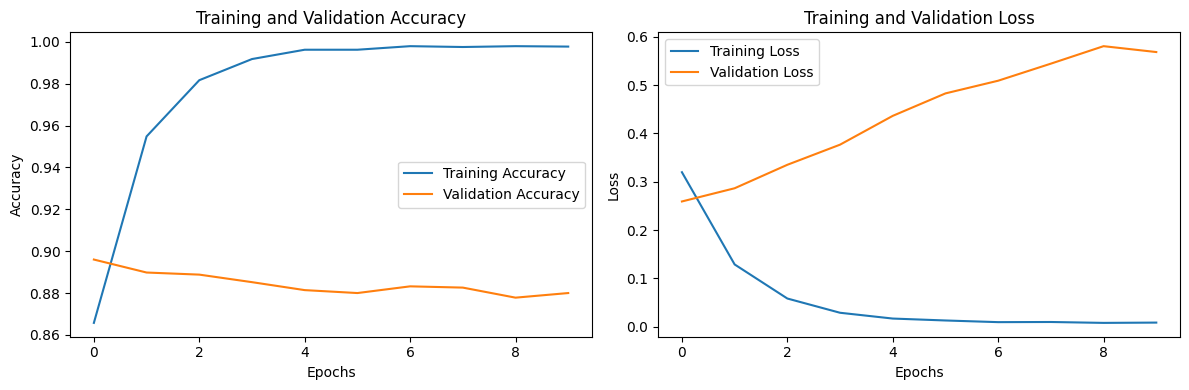

In [82]:
# Plot training and validation accuracy and loss as subplots
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    axs[0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    # Plot loss
    axs[1].plot(history.history['loss'], label='Training Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [86]:
loss, accuracy = bow_model.evaluate(test_ds)
print("Test accuracy:", accuracy)
print("Test loss:", loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8846 - loss: 0.5592
Test accuracy: 0.8845599889755249
Test loss: 0.5591595768928528


Prediction using a sample review text:

In [83]:
# 1. Define the reviews provided by the user
new_reviews = np.array([
    "This movie was fantastic. But I hate the ending because it feels rushed. "
    "The characters are well-developed and the plot is engaging. However, I believe a majority of them deserves more screen time. "
    "Overall, I enjoyed it.",
], dtype=object)

# 2. Predict probabilities (0 = Negative, 1 = Positive)
probabilities = bow_model.predict(new_reviews, verbose=0).reshape(-1)

# 3. Create a summary DataFrame
results = pd.DataFrame({
    "Review": new_reviews,
    "Positive Probability": np.round(probabilities, 3),
    "Predicted Sentiment": ["Positive" if p > 0.5 else "Negative" for p in probabilities]
})

display(results)

,Review,Positive Probability,Predicted Sentiment
0,This movie was fantastic. But I hate the endin...,1.0,Positive


We can also load a batch of the `unsup` reviews specifically to see what the model thinks of them.

In [88]:
unsup_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    class_names=['unsup'],
    batch_size=32
)

# Take a sample batch and predict
for text_batch, _ in unsup_ds.take(1):
    unsup_probs = bow_model.predict(text_batch, verbose=0)

    for i in range(5):
        review = text_batch[i].numpy().decode("utf-8")
        # Move to a new line after every sentence
        review = re.sub(r'([.!?])\s+', r'\1\n', review)
        
        print("-" * 100)
        print("Review:", review)
        print(f"Score: {unsup_probs[i][0]:.4f}")
        print(f"Label: {'Positive' if unsup_probs[i][0] > 0.5 else 'Negative'}")
        print("-" * 100)

Found 50000 files belonging to 1 classes.
----------------------------------------------------------------------------------------------------
Review: STAR RATING: ***** Saturday Night **** Friday Night *** Friday Morning ** Sunday Night * Monday Morning <br /><br />I'm rather glad I'm now a member of the internet based LoveFilm rather than still renting films from a video shop, because I'd hate to have to phone up and reserve this film.
The day when someone decided to make a documentary about the word fu*k was inevitable one day if you really think about it, and here it is.
If only the main contributions weren't from dumb Americans who haven't a clue the word is Anglo Saxon in origin and not an abbreviation (Fornicate Under Command of the King?!?) Although some interesting points are put across, such as the release one feels from using the word and it's traditional use with negativity and sexual encounters.
Although most of the talking heads are speaking in defence of the word, a few 

**2.2. Sequence Representation with Embeddings**

Embeddings are a way to represent words in a continuous vector space, capturing semantic relationships between words. We will use an embedding layer in our neural network to learn these representations from the text data.

In [89]:
seq_vectorizer = TextVectorization(max_tokens=20000, 
                                   output_mode="int", 
                                   output_sequence_length=200)
seq_vectorizer.adapt(train_text)

In [95]:
embedding = layers.Embedding(input_dim=20000, output_dim=128, 
                             mask_zero=True)

In [97]:
# Use the above sample review to demonstrate the sequence representation with embeddings
sample_review = "I hate the ending because it feels rushed. " \
"The characters are well-developed and the plot is engaging. However, I believe a majority of them deserves more screen time"

for review in [sample_review]:
    # Vectorize the review
    vectorized_review = seq_vectorizer(tf.constant([review]))

    # Get the embeddings for the vectorized review
    embedded_review = embedding(vectorized_review)
    
    print("Original Review:", review)
    print("Vectorized Review:", vectorized_review.numpy())
    print("Embedded Review Shape:", embedded_review.shape)

Original Review: I hate the ending because it feels rushed. The characters are well-developed and the plot is engaging. However, I believe a majority of them deserves more screen time
Vectorized Review: [[   10   798     2   274    84     9   736  3501     2   102    24 11366
      3     2   113     7  1755   190    10   257     4  2062     5    99
    992    51   289    62     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0  

In [98]:
# This is to demonstrate the shapes of the encoded, embedded, 
# and mask tensors for a batch of reviews from the training dataset.

for reviews, labels in train_ds.take(1):
    encoded = seq_vectorizer(reviews)
    embedded = embedding(encoded)
    mask = embedding.compute_mask(encoded)

    print("Encoded shape :", encoded.shape)
    print("Embedding shape :", embedded.shape)
    print("Mask shape :", mask.shape)

    break

Encoded shape : (32, 200)
Embedding shape : (32, 200, 128)
Mask shape : (32, 200)


**2.3. Positional Embeddings**

Positional embeddings are used to provide information about the position of words in a sequence, which is important for models that process sequences, such as transformers. We will explore how to implement positional embeddings in our model.

In [99]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, input_dim, 
                 output_dim, **kwargs,):

        super().__init__(**kwargs)

        self.token_embeddings = layers.Embedding(
            input_dim=input_dim,
            output_dim=output_dim,
            mask_zero=True,
        )

        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length,
            output_dim=output_dim,
        )

    def call(self, inputs):
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1,)

        token_embeddings = self.token_embeddings(inputs)
        position_embeddings = self.position_embeddings(positions)

        return token_embeddings + position_embeddings

    def compute_mask(self, inputs, mask=None):
        return self.token_embeddings.compute_mask(inputs)

In [100]:
pos_embedding = PositionalEmbedding(sequence_length=200, 
                                    input_dim=20000, 
                                    output_dim=128,)

for reviews, labels in train_ds.take(1):
    encoded = seq_vectorizer(reviews)
    output = pos_embedding(encoded)
    
    print(output.shape)
    break

(32, 200, 128)


### 3. Transformer Model

Transformers are a type of neural network architecture that has shown great success in NLP tasks. We will build a transformer model for text classification, which includes self-attention mechanisms and feedforward layers.

The three main components of a transformer model are:
- **Input Embedding Layer**: Converts input tokens into dense vectors.

- **Self-Attention Mechanism**: Allows the model to focus on different parts of the input sequence when making predictions.

- **Feedforward Neural Network**: Processes the output of the self-attention mechanism.

In [101]:
# Dummy encoded batch for demonstration
encoded_batch = tf.constant([[10, 20, 0, 0, 0, 0, 0, 0], [5, 15, 25, 0, 0, 0, 0, 0]])

pos_layer = PositionalEmbedding(sequence_length=8, input_dim=50, output_dim=6)
# TODO: gọi pos_layer(encoded_batch).
pos_output = pos_layer(encoded_batch)
print("Positional embedding output shape:", pos_output.shape)
print("\nPositional embedding output (first sample):\n", pos_output[0].numpy())

Positional embedding output shape: (2, 8, 6)

Positional embedding output (first sample):
 [[-0.00843575 -0.09190688 -0.08334731 -0.03081573  0.00567308  0.09390023]
 [ 0.01002448  0.07896775 -0.00180846 -0.07768027 -0.05013898  0.00627976]
 [-0.05822793  0.00885159 -0.06148224  0.04623267  0.00722871  0.0549798 ]
 [-0.04615539 -0.06630614  0.00191031  0.06684176  0.08268409  0.01926756]
 [-0.01973414  0.01957506  0.00105317  0.05110701  0.06371867 -0.01677057]
 [-0.01665185 -0.00073089  0.03260241  0.03197088  0.06296065  0.04907455]
 [-0.0178299  -0.00485845 -0.0667202   0.06408177  0.02068174  0.00490346]
 [ 0.00829329  0.00289339 -0.04924898  0.04396974  0.01439097  0.02592533]]


In the self-attention mechanism, we will compute the attention weights and use them to create a weighted sum of the input representations. This allows the model to capture dependencies between words in the input sequence, regardless of their distance from each other.

In [ ]:
def scaled_dot_product_attention(query, key, value):
    # Calculate the attention weights based on scaled dot product attention.
    # Compute QKᵀ
    matmul_qk = np.matmul(query, np.transpose(key, (0, 2, 1)))

    # Scale
    dk = key.shape[-1]
    scaled_attention_logits = matmul_qk / np.sqrt(dk)

    # Softmax
    attention_weights = tf.nn.softmax(scaled_attention_logits, 
                                      axis=-1).numpy()

    # Weighted sum
    output = np.matmul(attention_weights, value)

    return output, attention_weights

We store three matrices: Query, Key, and Value.
- The Query matrix represents the current word we are focusing on.

- The Key matrix represents all the words in the input sequence.

- The Value matrix represents the actual information we want to extract from the input sequence.

In [105]:
sentence = ["the", "train", "left", "the", "station", "on", "time"]

seq_len = len(sentence)
d_model = 4

np.random.seed(42)

query = np.random.rand(1, seq_len, d_model)
key   = np.random.rand(1, seq_len, d_model)
value = np.random.rand(1, seq_len, d_model)

attention_output, attention_weights = scaled_dot_product_attention(query, key, value)

print("Attention Output shape:", attention_output.shape)
print("Attention Weights shape:", attention_weights.shape)

print("\nAttention Output:\n", attention_output[0])
print("\nAttention Weights:\n", attention_weights[0])

Attention Output shape: (1, 7, 4)
Attention Weights shape: (1, 7, 7)

Attention Output:
 [[0.41328448 0.48839517 0.48142848 0.33676722]
 [0.38088653 0.50947586 0.47366336 0.34797641]
 [0.40648772 0.51703702 0.47976485 0.33081253]
 [0.39229039 0.49140717 0.44140833 0.3468295 ]
 [0.38915413 0.49212195 0.46612475 0.35072345]
 [0.39140496 0.48945218 0.44758938 0.34795563]
 [0.39703407 0.50710182 0.47657851 0.34146649]]

Attention Weights:
 [[0.10157574 0.19500347 0.10995071 0.11644191 0.12742571 0.14715987
  0.20244259]
 [0.11298707 0.15496146 0.12493797 0.15276449 0.1332318  0.14943571
  0.17168149]
 [0.10000437 0.16065047 0.10652657 0.14476157 0.13288944 0.1394089
  0.21575868]
 [0.14006734 0.13556941 0.12895585 0.12268572 0.13082029 0.15234572
  0.18955566]
 [0.12153801 0.16851149 0.12467499 0.12523631 0.13403819 0.14779396
  0.17820704]
 [0.13373116 0.14353691 0.13057542 0.12581837 0.12870844 0.1568264
  0.1808033 ]
 [0.10931405 0.16868134 0.11280805 0.13373529 0.13704997 0.13834336
  

Create a simple Transformer block that includes the self-attention mechanism and feedforward layers. We will then use this block to build a complete transformer model for text classification.

In [106]:
class SimpleTransformerBlock:
    def __init__(self, d_model, d_ff):
        self.d_model = d_model
        self.d_ff = d_ff

        self.ffn_w1 = np.random.rand(d_model, d_ff) * 0.1
        self.ffn_b1 = np.random.rand(1, d_ff) * 0.1

        self.ffn_w2 = np.random.rand(d_ff, d_model) * 0.1
        self.ffn_b2 = np.random.rand(1, d_model) * 0.1

    def feed_forward(self, x):

        hidden = np.maximum(0, np.matmul(x, self.ffn_w1) + self.ffn_b1)
        output = np.matmul(hidden, self.ffn_w2) + self.ffn_b2
        return output

    def call(self, x):

        attention_output, _ = scaled_dot_product_attention(x, x, x)

        # Residual connection
        attention_output = attention_output + x

        # Feed-forward network
        ffn_output = self.feed_forward(attention_output)
        # Residual connection
        ffn_output = ffn_output + attention_output

        return ffn_output

In [107]:
# Test the SimpleTransformerBlock with a dummy input
batch_size = 1
seq_len = 5

d_model = 64
d_ff = 128

x = np.random.rand(batch_size, seq_len, d_model)
transformer_block = SimpleTransformerBlock(d_model, d_ff)

output = transformer_block.call(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

print(output[0, :2, :5])

Input shape: (1, 5, 64)
Output shape: (1, 5, 64)
[[20.27385289 20.49456842 21.77016518 20.93954099 22.34990271]
 [19.80365965 20.27802678 21.76127071 20.23812619 21.24099152]]


### 4. Sequence-to-Sequence Models

Sequence-to-sequence (seq2seq) models are used for tasks where the input and output are both sequences, such as machine translation. We will explore how to build seq2seq models using recurrent neural networks (RNNs) and transformers.

In [113]:
# Some toy English-Spanish pairs for sequence-to-sequence.
pairs = [
    ("how is the weather today", "qué tiempo hace hoy"),
    ("i like this movie", "me gusta esta película"),
    ("she can play piano", "ella puede tocar piano"),
    ("this book is good", "este libro es bueno"),
]

source_texts = [src for src, tgt in pairs]
target_texts = [tgt for src, tgt in pairs]

In [114]:
target_texts = ["[start] " + tgt + " [end]" for
                 tgt in target_texts]

In [115]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "").replace("]", "")


def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)

    return tf.strings.regex_replace(lowercase, 
                                    f"[{re.escape(strip_chars)}]", "")

In [116]:
source_vectorization = TextVectorization(
    max_tokens=50,
    output_mode="int",
    output_sequence_length=8,
    standardize=custom_standardization
)

target_vectorization = TextVectorization(
    max_tokens=50,
    output_mode="int",
    output_sequence_length=9,
    standardize=custom_standardization,
)

In [117]:
source_vectorization.adapt(source_texts)
target_vectorization.adapt(target_texts)

source_encoded = source_vectorization(source_texts)
target_encoded = target_vectorization(target_texts)

In [118]:
decoder_inputs = target_encoded[:, :-1]
target_outputs = target_encoded[:, 1:]

Causal Attention Mask is used in sequence-to-sequence models to ensure that the model only attends to previous tokens in the input sequence when generating the output sequence. This prevents the model from "cheating" by looking ahead at future tokens.

In [119]:
def causal_attention_mask(size):
    mask = tf.linalg.band_part(tf.ones((size, size)), -1, 0)
    return mask

In [120]:
print("source_encoded shape:", source_encoded.shape)
print("decoder_inputs shape:", decoder_inputs.shape)
print("target_outputs shape:", target_outputs.shape)

print(causal_attention_mask(8))

source_encoded shape: (4, 8)
decoder_inputs shape: (4, 8)
target_outputs shape: (4, 8)
tf.Tensor(
[[1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1.]], shape=(8, 8), dtype=float32)
